# Model selection!

First, let us continue where we left off in part 2, with the model pipeline:

In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import time

In [6]:
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score

#Redo data:
y_train = pd.read_csv('./data/y_train.csv')
y_test = pd.read_csv('./data/y_test.csv')
X_train = pd.read_csv('./data/x_train.csv')
X_test = pd.read_csv('./data/x_test.csv')

In [11]:
# %run ML_Lifecycle_Step2_Pipeline.ipynb import X, y
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold


# Let's pick our models here:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": xgb.XGBClassifier(),
    "LightGBM": lgb.LGBMClassifier(),
    "CatBoost": CatBoostClassifier(),
}

# For evaluation
training_time = {}
prediction_time = {}
accuracy_scores = {}

# Loop
for model_name, model in models.items():
    # Time to train
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time[model_name] = time.time() - start_time

    # Time to predict
    start_time = time.time()
    prediction = model.predict(X_test)
    prediction_time[model_name] = time.time() - start_time

    # Time for accuracy
    accuracy_scores[model_name] = accuracy_score(y_test, prediction)

# Comparison table:
results = pd.DataFrame({
    "model_name": list(models.keys()),
    "training_time": list(training_time.values()),
    "prediction_time": list(prediction_time.values()),
    "accuracy_scores": list(accuracy_scores.values())
})

results

C:\Users\haaze\PycharmProjects\data-5-mushroom\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\haaze\PycharmProjects\data-5-mushroom\.venv\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\haaze\PycharmProjects\data-5-mushroom\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\haaze\PycharmProjects\data-5-mushroom\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:239: Dat

[LightGBM] [Info] Number of positive: 3133, number of negative: 3366
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000578 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 206
[LightGBM] [Info] Number of data points in the train set: 6499, number of used features: 103
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.482074 -> initscore=-0.071734
[LightGBM] [Info] Start training from score -0.071734
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,model_name,training_time,prediction_time,accuracy_scores
0,Logistic Regression,0.055356,0.001288,0.998769
1,Decision Tree,0.014683,0.001276,1.000000
2,Random Forest,0.168171,0.007842,1.000000
3,SVM,0.234599,0.073232,1.000000
4,KNN,0.007223,2.571950,1.000000
5,Gradient Boosting,0.803223,0.002783,0.998769
6,Naive Bayes,0.007473,0.003140,0.988923
7,XGBoost,0.196184,0.007198,1.000000
8,LightGBM,0.054988,0.002203,1.000000
9,CatBoost,2.047293,0.004128,1.000000


## Hyperparam tuning:
Let's try to do some parameter tuning on the models that aren't perfect (Logistic regression, Gradient boosting, Naive Bayes)

In [8]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

# First making the param grid:
param_grid = {
    'logistic_regression': {
        'clf__C': [0.1, 1, 10],
        # 'clf__gamma': [0.1, 1, 10],
        'clf__penalty': ['l1', 'l2'],
        'clf__solver': ['lbfgs', 'liblinear', 'sag', 'saga']
    },
    'gradient_boosting': {
        'clf__learning_rate': [0.01, 0.1, 0.2],
        'clf__n_estimators': [100, 200, 300], # boosting stages
        'clf__max_depth': [3, 5, 7],
        'clf__min_samples_split': [2, 5, 10],
        'clf__subsample': [0.6, 0.8, 1.0]
    },
    'naive_bayes': {
        'clf__var_smoothing': [0.1, 0.5, 1.0] # apparently always has low hyperparams except for the smoothing curve
    }
}

# REdoing models here because it's easier
param_models = {
    "logistic_regression": LogisticRegression(),
    "gradient_boosting": GradientBoostingClassifier(),
    "naive_bayes": GaussianNB()
}

# Cross validation!
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
collection_best_models = []
best_models = {}

#Loop
for model_name, model in param_models.items():
    estimator = Pipeline(steps=[('clf', model)])
    grid_search = GridSearchCV(
        param_grid=param_grid[model_name],
        cv=cv,
        scoring='accuracy',
        estimator= estimator
    )
    grid_search.fit(X_train, y_train)

    best_models[model_name] = grid_search.best_estimator_
    predicted = grid_search.best_estimator_.predict(X_test)
    accuracy = accuracy_score(y_test, predicted)
    f1_s = f1_score(y_test, predicted, average='macro')

    collection_best_models.append({
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_score': f1_score,
        'best_parameters': grid_search.best_params_,
        'best_accuracy': grid_search.best_score_,
    })

# Out of loop: conclusion
ranking = pd.DataFrame(collection_best_models).sort_values('accuracy', ascending=False)
print(ranking[['model_name', 'accuracy']]) #keep it simple



C:\Users\haaze\PycharmProjects\data-5-mushroom\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\haaze\PycharmProjects\data-5-mushroom\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\haaze\PycharmProjects\data-5-mushroom\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\haaze\PycharmProjects\data-5-mushroom\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversio

            model_name  accuracy
0  logistic_regression  1.000000
1    gradient_boosting  0.998769
2          naive_bayes  0.971692


C:\Users\haaze\PycharmProjects\data-5-mushroom\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\haaze\PycharmProjects\data-5-mushroom\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\haaze\PycharmProjects\data-5-mushroom\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\haaze\PycharmProjects\data-5-mushroom\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversio

In [9]:
print(ranking[['model_name', 'accuracy']]) #keep it simple


            model_name  accuracy
0  logistic_regression  1.000000
1    gradient_boosting  0.998769
2          naive_bayes  0.971692


# Hyperparameter optimisation:
As you can see the accuracy has improved!
For logistic regression we went from 0.998769 to 1.00
Gradient boosting stayed the same at 0.998769. (This means we already had the most optimal model)
and naive bayes went from 0.988923 to 0.971692, which decreased (Our gridsearch didn't include the best var smoothing)

# Choosing the best model:
Let us now rank all the remaining models with 1.00 accuracy based on training and prediction time. This shows how resource intensive these models are, and pick the best one.

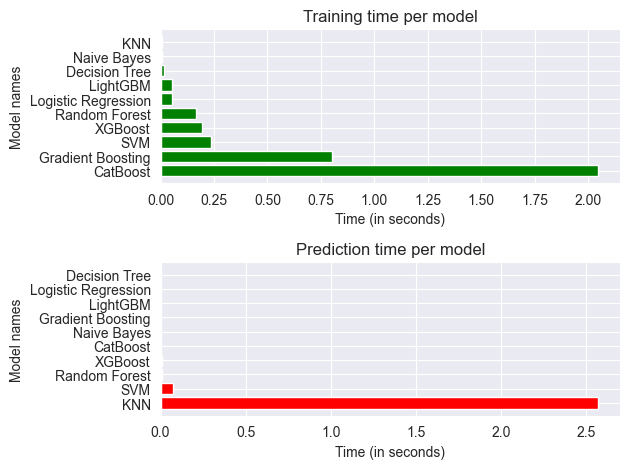

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
def plot_models(model_results):
    fig, ax = plt.subplots(nrows=2, ncols=1)

    # Training:
    results = model_results.sort_values('training_time', ascending=False) # Sorting for the graph

    ax[0].barh(results['model_name'], results['training_time'], color='green')
    ax[0].set_title('Training time per model')
    ax[0].set_ylabel('Model names')
    ax[0].set_xlabel('Time (in seconds)')

    # Prediction:
    results = model_results.sort_values('prediction_time', ascending=False) # Sorting for the graph again

    ax[1].barh(results['model_name'], results['prediction_time'], color='red')
    ax[1].set_title('Prediction time per model')
    ax[1].set_ylabel('Model names')
    ax[1].set_xlabel('Time (in seconds)')

    plt.tight_layout()
    plt.show()

plot_models(results)

Here we can see that KNN is the least efficient by far, let's now remove all models the models that did not get 100% accuracy and scored badly in prediction & training time:

In [26]:
# List of worst models:
bad_models = ['KNN', 'SVM', 'Random Forest', 'XGBoost', 'CatBoost', 'Gradient Boosting', 'Naive Bayes']
drop_indices = results[results['model_name'].isin(bad_models)].index
new_results = results.drop(drop_indices)

print(new_results)

            model_name  training_time  prediction_time  accuracy_scores
8             LightGBM       0.054988         0.002203         1.000000
0  Logistic Regression       0.055356         0.001288         0.998769
1        Decision Tree       0.014683         0.001276         1.000000


In [41]:
# Obtain LR model from hyperparam training instead of the original one:
print(list(ranking[['best_parameters', 'accuracy']].iloc[0]))
new_LR_model = LogisticRegression(C=10, penalty='l1', solver='liblinear')

# Train only LR again:
start_time = time.time()
new_LR_model.fit(X_train, y_train)
new_results.loc[new_results['model_name'] == 'Logistic Regression', 'training_time'] = time.time() - start_time

# Time to predict
start_time = time.time()
LR_prediction = new_LR_model.predict(X_test)
new_results.loc[new_results['model_name'] == 'Logistic Regression', 'prediction_time'] = time.time() - start_time

new_results.loc[new_results['model_name'] == 'Logistic Regression', 'accuracy_scores'] = accuracy_score(y_test, LR_prediction)

print(new_results)

[{'clf__C': 10, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}, np.float64(1.0)]
            model_name  training_time  prediction_time  accuracy_scores
8             LightGBM       0.054988         0.002203              1.0
0  Logistic Regression       0.017993         0.000992              1.0
1        Decision Tree       0.014683         0.001276              1.0


C:\Users\haaze\PycharmProjects\data-5-mushroom\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# Final comparison:
Let's now call the graph plotting function again and compare our top three models:

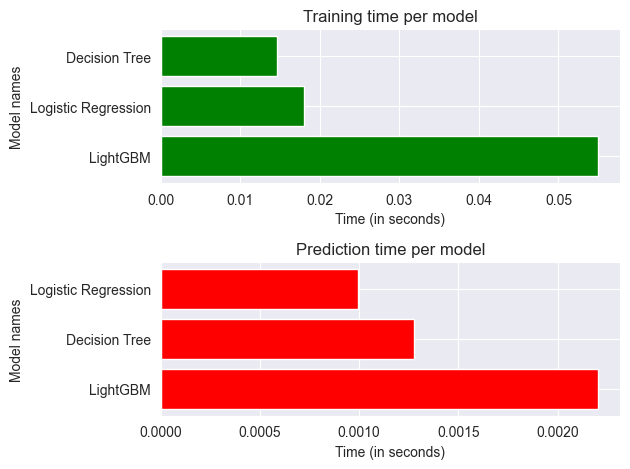

In [44]:
plot_models(new_results)